# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
import pandas as pd
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM
from utils import hyperparam_tuning

In [2]:
# have GPU available to speed up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cpu


In [3]:
# Create understat connection
understat = UnderstatClient()

In [4]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 10

In [ ]:
### ONLY UNCOMMENT IF NEED TO PULL NEW POSITION DATA ###
### MAKE SURE THAT YOU CHANGE DF NAME ###

# Get forward stats for all seasons in top 5 leagues
leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
seasons = list(range(2014,2026))
positions = ['M'] # forwards saved to csv, no need to run again
# 
f_stats = get_position_players_stats_df(understat, positions, games_per_block, stats, leagues=leagues, seasons=seasons)
f_stats.head()
# 
# # save dataset to csv to avoid pulls from understat every time as it can take 5-10min for just one position
# os.makedirs("data", exist_ok=True)  
# 
# # to be able to save datasets for a set of positions
f_stats.to_csv(f"../data/{'_'.join(positions)}_stats.csv", index=True)

Caught error 29084 is not a valid match, skipping match.
Caught error 29088 is not a valid match, skipping match.
Caught error 29089 is not a valid match, skipping match.
Caught error 29090 is not a valid match, skipping match.
Caught error 29091 is not a valid match, skipping match.
Caught error 29092 is not a valid match, skipping match.
Caught error 29093 is not a valid match, skipping match.
Caught error 29094 is not a valid match, skipping match.
Caught error 29095 is not a valid match, skipping match.
Caught error 29096 is not a valid match, skipping match.
Caught error 29097 is not a valid match, skipping match.
Caught error 29098 is not a valid match, skipping match.
Caught error 29099 is not a valid match, skipping match.
Caught error 29100 is not a valid match, skipping match.
Caught error 29101 is not a valid match, skipping match.
Caught error 29102 is not a valid match, skipping match.
Caught error 29103 is not a valid match, skipping match.
Caught error 29104 is not a val

In [9]:
f_stats

goals_per_90  xG_per_90  \
player_id player_name        date                                           
140       Yannick Gerhardt   2015-11-21 18:30:00      0.207852   0.076191   
                             2016-03-05 18:30:00      0.111940   0.147187   
                             2021-08-14 13:30:00      0.000000   0.004439   
                             2021-12-17 19:30:00      0.000000   0.038612   
                             2022-04-03 13:30:00      0.000000   0.143876   
...                                                        ...        ...   
12387     Dehmaine Assoumani 2026-03-01 16:15:00      0.000000   0.090301   
1935      Marko Livaja       2015-11-29 21:00:00      0.227848   0.134744   
                             2016-08-28 20:15:00      0.501393   0.113124   
                             2016-12-10 21:30:00      0.254237   0.174652   
                             2017-04-06 18:30:00      0.189474   0.166665   

                                                  assists_per_90  xA_per_90  \
player_id player_name        date                                             
140       Yannick Gerhardt   2015-11-21 18:30:00        0.000000   0.152804   
                             2016-03-05 18:30:00        0.111940   0.097708   
                             2021-08-14 13:30:00        0.412214   0.149183   
                             2021-12-17 19:30:00        0.000000   0.122557   
                             2022-04-03 13:30:00        0.000000   0.016857   
...                                                          ...        ...   
12387     Dehmaine Assoumani 2026-03-01 16:15:00        0.000000   0.144073   
1935      Marko Livaja       2015-11-29 21:00:00        0.000000   0.140569   
                             2016-08-28 20:15:00        0.250696   0.031969   
                             2016-12-10 21:30:00        0.254237   0.087571   
                             2017-04-06 18:30:00        0.000000   0.179576   

                                                  key_passes_per_90  \
player_id player_name        date                                     
140       Yannick Gerhardt   2015-11-21 18:30:00           1.454965   
                             2016-03-05 18:30:00           1.119403   
                             2021-08-14 13:30:00           0.961832   
                             2021-12-17 19:30:00           0.432000   
                             2022-04-03 13:30:00           0.623557   
...                                                             ...   
12387     Dehmaine Assoumani 2026-03-01 16:15:00           1.581722   
1935      Marko Livaja       2015-11-29 21:00:00           1.139241   
                             2016-08-28 20:15:00           0.752089   
                             2016-12-10 21:30:00           1.271186   
                             2017-04-06 18:30:00           1.515789   

                                                  xGChain_per_90  \
player_id player_name        date                                  
140       Yannick Gerhardt   2015-11-21 18:30:00        0.276498   
                             2016-03-05 18:30:00        0.419527   
                             2021-08-14 13:30:00        0.423672   
                             2021-12-17 19:30:00        0.267215   
                             2022-04-03 13:30:00        0.317156   
...                                                          ...   
12387     Dehmaine Assoumani 2026-03-01 16:15:00        0.188675   
1935      Marko Livaja       2015-11-29 21:00:00        0.340784   
                             2016-08-28 20:15:00        0.203323   
                             2016-12-10 21:30:00        0.345903   
                             2017-04-06 18:30:00        0.209934   

                                                  xGBuildup_per_90  
player_id player_name        date                                   
140       Yannick Gerhardt   2015-11-21 18:30:00          0.165737  
    

In [10]:
# Read in saved df
f_stats_df = pd.read_csv(f"../data/{'_'.join(positions)}_stats_2.csv").set_index(['player_id', 'player_name', 'date'])

f_stats_df.head()

### MAKE SURE THAT YOU CHANGE DF NAME IF NEW CSV ###
### AND THAT ALL DF BELOW ARE UPDATED TO MATCH NEW DF NAME ###

goals_per_90  xG_per_90  \
player_id player_name      date                                           
140       Yannick Gerhardt 2015-11-21 18:30:00      0.207852   0.076191   
                           2016-03-05 18:30:00      0.111940   0.147187   
                           2021-08-14 13:30:00      0.000000   0.004439   
                           2021-12-17 19:30:00      0.000000   0.038612   
                           2022-04-03 13:30:00      0.000000   0.143876   

                                                assists_per_90  xA_per_90  \
player_id player_name      date                                             
140       Yannick Gerhardt 2015-11-21 18:30:00        0.000000   0.152804   
                           2016-03-05 18:30:00        0.111940   0.097708   
                           2021-08-14 13:30:00        0.412214   0.149183   
                           2021-12-17 19:30:00        0.000000   0.122557   
                           2022-04-03 13:30:00        0.000000   0.016857   

                                                key_passes_per_90  \
player_id player_name      date                                     
140       Yannick Gerhardt 2015-11-21 18:30:00           1.454965   
                           2016-03-05 18:30:00           1.119403   
                           2021-08-14 13:30:00           0.961832   
                           2021-12-17 19:30:00           0.432000   
                           2022-04-03 13:30:00           0.623557   

                                                xGChain_per_90  \
player_id player_name      date                                  
140       Yannick Gerhardt 2015-11-21 18:30:00        0.276498   
                           2016-03-05 18:30:00        0.419527   
                           2021-08-14 13:30:00        0.423672   
                           2021-12-17 19:30:00        0.267215   
                           2022-04-03 13:30:00        0.317156   

                                                xGBuildup_per_90  
player_id player_name      date                                   
140       Yannick Gerhardt 2015-11-21 18:30:00          0.165737  
                           2016-03-05 18:30:00          0.204866  
                           2021-08-14 13:30:00          0.274489  
                           2021-12-17 19:30:00          0.123039  
                           2022-04-03 13:30:00          0.181113

In [11]:
# Train/test split
train_len = int(len(f_stats_df) * 0.8)
train_df = f_stats_df.iloc[:train_len]
test_df = f_stats_df.iloc[train_len:]

In [12]:
train_df.head()

goals_per_90  xG_per_90  \
player_id player_name      date                                           
140       Yannick Gerhardt 2015-11-21 18:30:00      0.207852   0.076191   
                           2016-03-05 18:30:00      0.111940   0.147187   
                           2021-08-14 13:30:00      0.000000   0.004439   
                           2021-12-17 19:30:00      0.000000   0.038612   
                           2022-04-03 13:30:00      0.000000   0.143876   

                                                assists_per_90  xA_per_90  \
player_id player_name      date                                             
140       Yannick Gerhardt 2015-11-21 18:30:00        0.000000   0.152804   
                           2016-03-05 18:30:00        0.111940   0.097708   
                           2021-08-14 13:30:00        0.412214   0.149183   
                           2021-12-17 19:30:00        0.000000   0.122557   
                           2022-04-03 13:30:00        0.000000   0.016857   

                                                key_passes_per_90  \
player_id player_name      date                                     
140       Yannick Gerhardt 2015-11-21 18:30:00           1.454965   
                           2016-03-05 18:30:00           1.119403   
                           2021-08-14 13:30:00           0.961832   
                           2021-12-17 19:30:00           0.432000   
                           2022-04-03 13:30:00           0.623557   

                                                xGChain_per_90  \
player_id player_name      date                                  
140       Yannick Gerhardt 2015-11-21 18:30:00        0.276498   
                           2016-03-05 18:30:00        0.419527   
                           2021-08-14 13:30:00        0.423672   
                           2021-12-17 19:30:00        0.267215   
                           2022-04-03 13:30:00        0.317156   

                                                xGBuildup_per_90  
player_id player_name      date                                   
140       Yannick Gerhardt 2015-11-21 18:30:00          0.165737  
                           2016-03-05 18:30:00          0.204866  
                           2021-08-14 13:30:00          0.274489  
                           2021-12-17 19:30:00          0.123039  
                           2022-04-03 13:30:00          0.181113

In [13]:
# Create datasets
blocks_per_input = 5

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [14]:
len(train_dataset)

7064

In [49]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [50]:
# Tuning params
params = {
    "learning_rates": [0.01, 0.001],      
    "epochs": [20],        
    "layers": [1, 2],                            
    "h_sizes": [32, 64, 128, 256],                  
    "dropouts": [0.3]                
}

opt_hyper_params = hyperparam_tuning(params, stats_df=f_stats_df, train_dataloader=train_dataloader, 
                                             test_dataloader=test_dataloader)

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {opt_hyper_params['learning_rate']} 
      - number of epochs: {opt_hyper_params['epoch']}.
      - number of layers: {opt_hyper_params['layers']}.
      - hidden size: {opt_hyper_params['hidden_size']}.
      - dropout: {opt_hyper_params['dropout']}.
      """)

learning_rates:   0%|          | 0/2 [00:00<?, ?it/s]

epochs:   0%|          | 0/1 [00:00<?, ?it/s]

layers:   0%|          | 0/2 [00:00<?, ?it/s]

h_sizes:   0%|          | 0/4 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [18]:
# Tuned setup to MSE Loss and Adam
loss_fn = nn.MSELoss()
model = FootballLSTM(n_features=len(f_stats_df.columns), hidden_size=opt_hyper_params['hidden_size'], 
                     num_layers=opt_hyper_params['layers'], dropout=opt_hyper_params['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=opt_hyper_params['learning_rate'])
num_epochs = opt_hyper_params['epoch']

# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs,
    test_every=float('inf')
)

In [19]:
# Evaluate test performance

rmse, mae = model.eval_model(test_dataloader)
print(f"Test RMSE: {rmse}")
print(f"Test MAE: {mae}")

Test RMSE: 0.24093571305274963
Test MAE: 0.17481453716754913


RMSE: 0.1891907900571823
MAE: 0.1568872183561325
goals_per_90 RMSE: 0.24776019155979156
goals_per_90 MAE: 0.18770036101341248
xG_per_90 RMSE: 0.11731621623039246
xG_per_90 MAE: 0.1042262613773346
assists_per_90 RMSE: 0.18511076271533966
assists_per_90 MAE: 0.1479291468858719
xA_per_90 RMSE: 0.10348544269800186
xA_per_90 MAE: 0.08380618691444397
key_passes_per_90 RMSE: 0.4551646113395691
key_passes_per_90 MAE: 0.38984817266464233
xGChain_per_90 RMSE: 0.1437234729528427
xGChain_per_90 MAE: 0.11829599738121033
xGBuildup_per_90 RMSE: 0.07177484035491943
xGBuildup_per_90 MAE: 0.0664042979478836


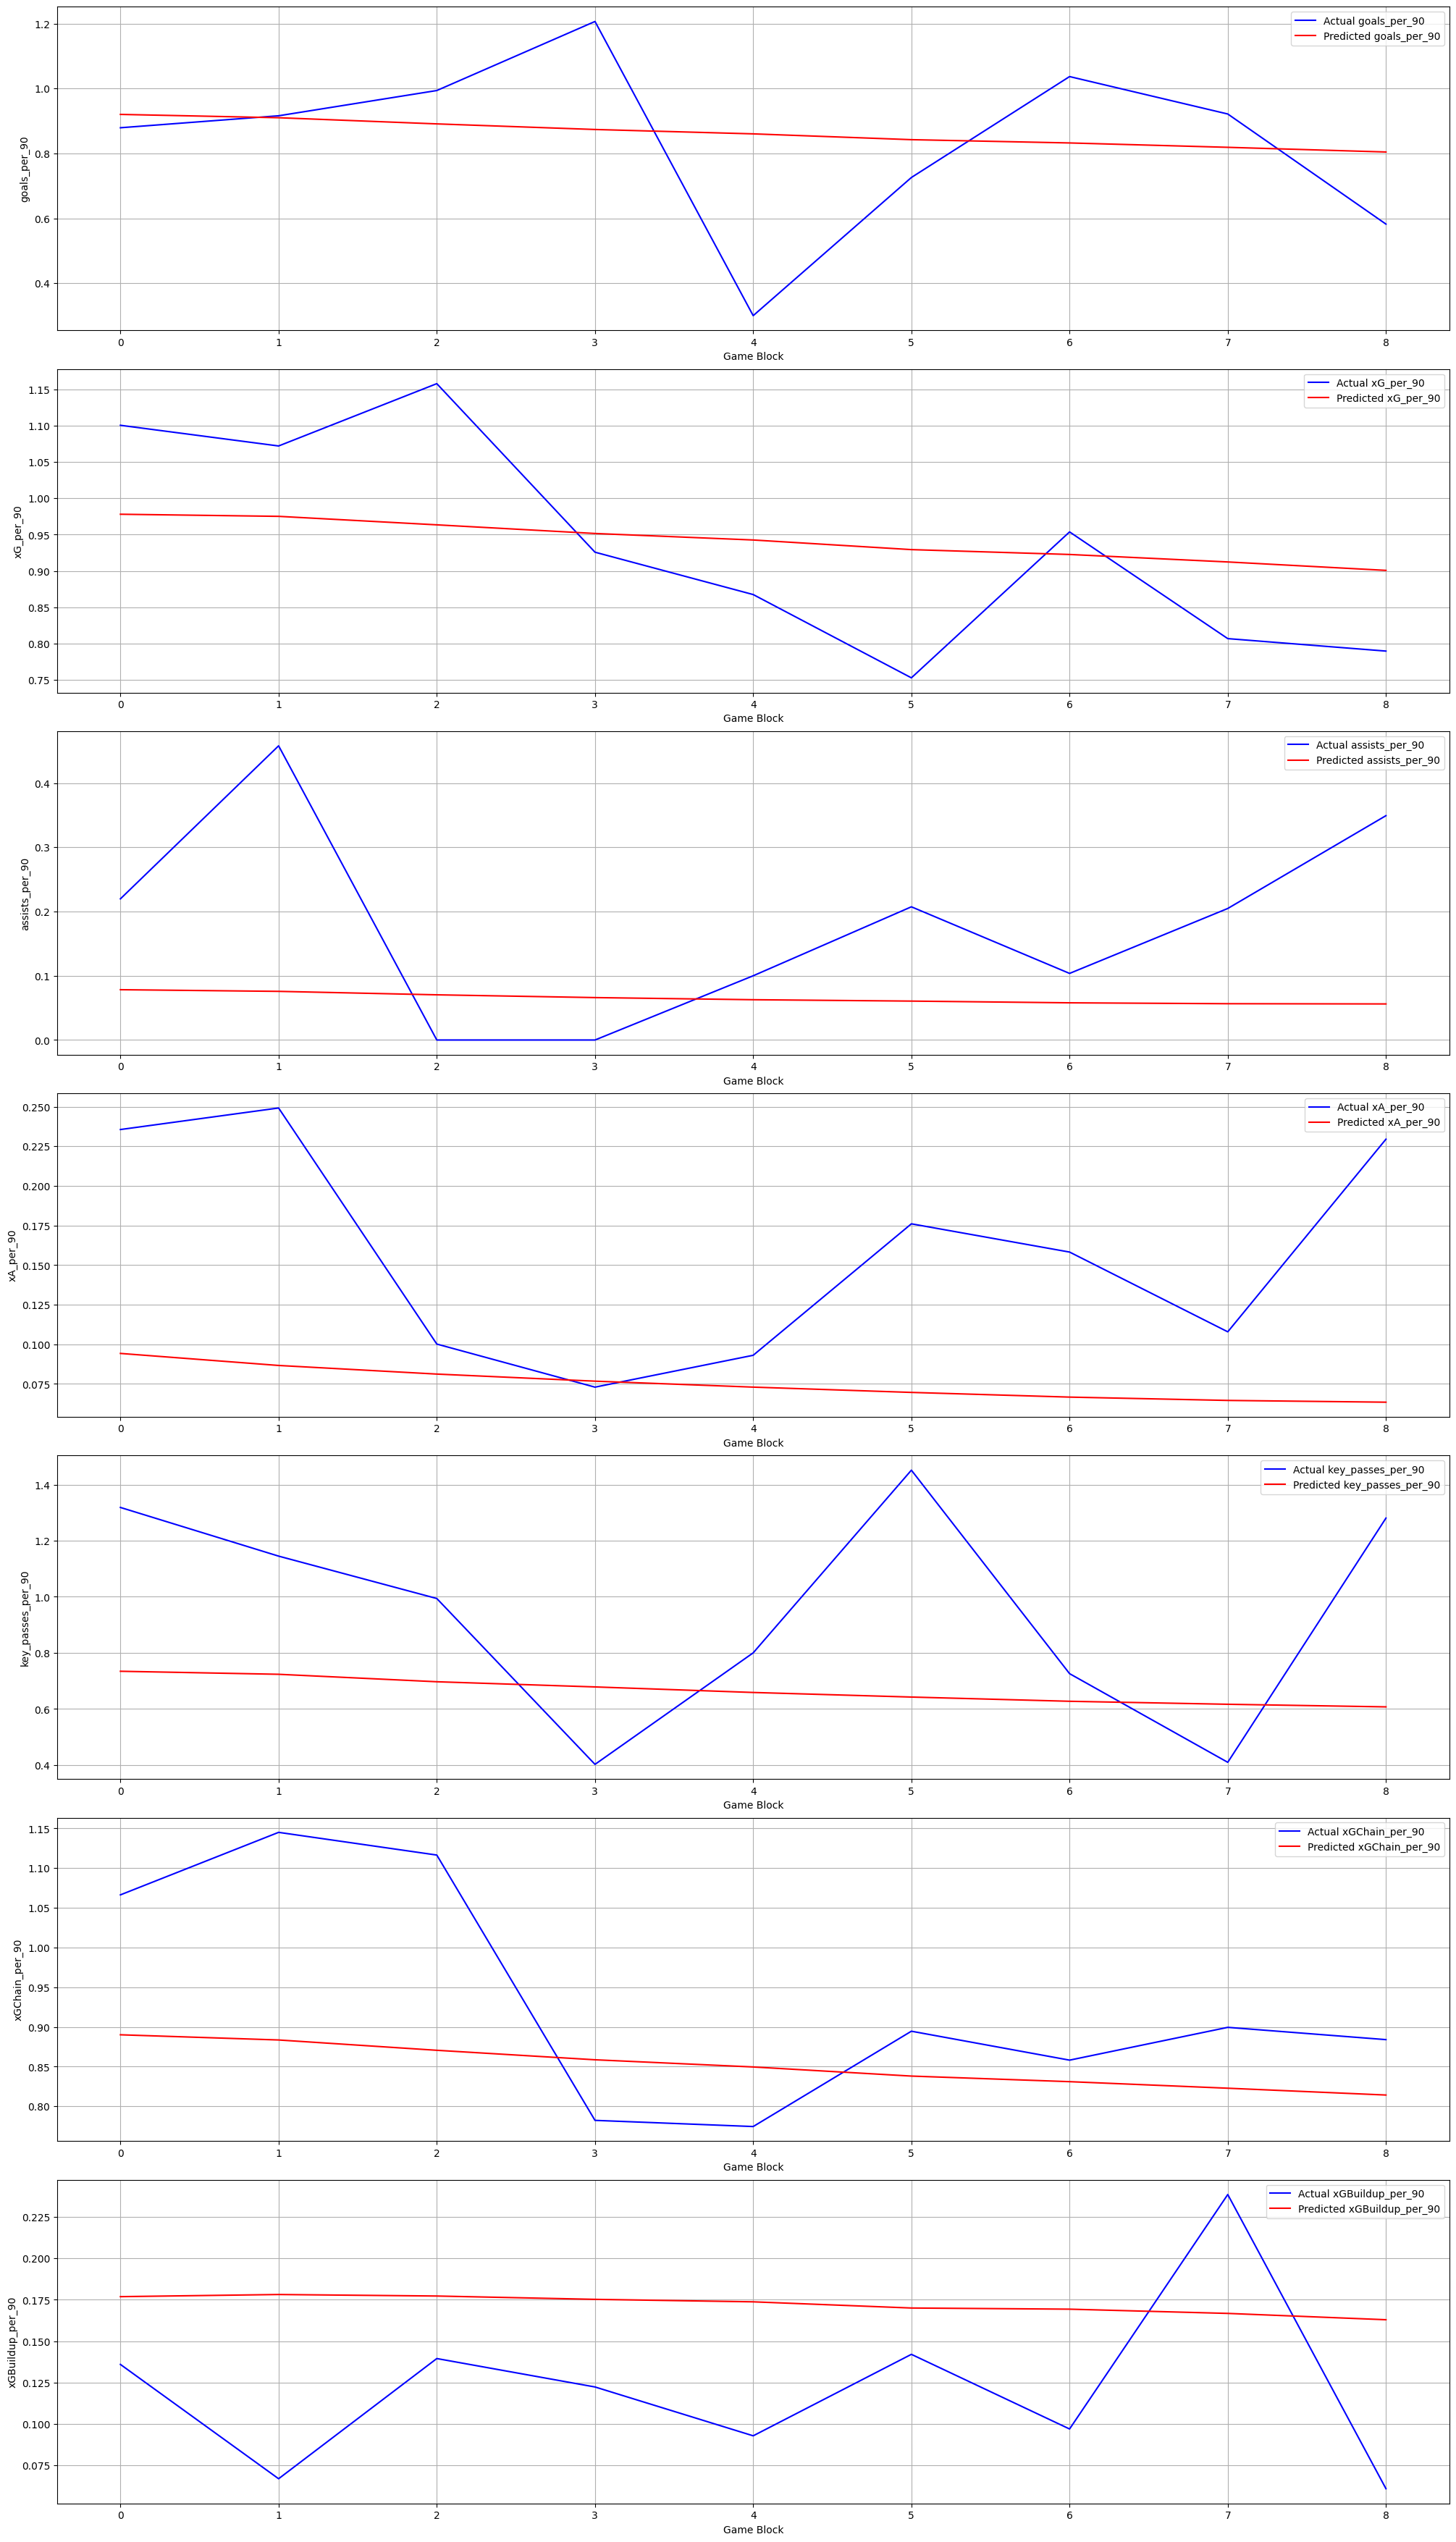

In [20]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats_df.loc[8260]

model.eval_model_on_player(haaland_df)

In [21]:
# Get predictions for each player and save to csv

# For each player, get most recent blocks_per_input games, then predict next k
# with LSTM.

ids = []
preds = []

k = 20

for id, player_df in f_stats_df.groupby("player_id"):
    vals = player_df.values
    if len(vals) >= blocks_per_input:
        x = torch.tensor(vals[-blocks_per_input:], dtype=torch.float32).unsqueeze(0)
        player_preds = model.predict_next_k(x, k=k).squeeze(0).detach().cpu().numpy()
        preds.append(player_preds)
        ids.extend([id] * k)
        
preds = np.concatenate(preds)

In [22]:
# Turn into a df
preds_df = pd.DataFrame(preds)
# Add id column
preds_df.insert(0, 'player_id', ids)
preds_df.head()

,player_id,0,1,2,3,4,5,6
0,9,0.127399,0.143873,0.151275,0.196117,1.813980,0.400490,0.201974
1,9,0.147003,0.160905,0.156484,0.206940,1.807822,0.444534,0.219733
2,9,0.154434,0.169717,0.157634,0.206653,1.743407,0.466413,0.227228
3,9,0.163737,0.178731,0.156779,0.205658,1.717318,0.477955,0.227257
4,9,0.134810,0.153944,0.158027,0.203921,1.629773,0.475384,0.234581


In [26]:
# Add name column
id_names = pd.read_csv("../data/id_names.csv")
id_names["player_id"] = id_names["player_id"].astype("int64")

preds_df_names = pd.merge(preds_df, id_names, how="inner", on="player_id")
preds_df_names = preds_df_names[["player_id", "name", 0,1,2,3,4,5,6]]

preds_df_names.head()

,player_id,name,0,1,2,3,4,5,6
0,9,Tobias Kempe,0.127399,0.143873,0.151275,0.196117,1.813980,0.400490,0.201974
1,9,Tobias Kempe,0.147003,0.160905,0.156484,0.206940,1.807822,0.444534,0.219733
2,9,Tobias Kempe,0.154434,0.169717,0.157634,0.206653,1.743407,0.466413,0.227228
3,9,Tobias Kempe,0.163737,0.178731,0.156779,0.205658,1.717318,0.477955,0.227257
4,9,Tobias Kempe,0.134810,0.153944,0.158027,0.203921,1.629773,0.475384,0.234581


In [24]:
# Save to csv
preds_df_names.to_csv(f"../data/F_predictions_next_{k}.csv")